In [1]:
import lsdb
import time
import sys
import numpy as np
from dask.distributed import Client

def measure_metrics(catalog, with_client=False, verbose=True, optimize=True, **kwargs):

    if with_client:
        client=Client(n_workers=1, threads_per_worker=1, **kwargs)
    if optimize:
        graph = catalog._ddf.optimize().dask
    else:
        graph = catalog._ddf.dask

    # Measure graph length
    graph_len = len(graph)

    # Measure graph size in memory
    graph_size = 0
    for key in graph.keys():
        graph_size+=sys.getsizeof(graph[key])

    # Measure Execution time
    t0 = time.time()
    if optimize:
        catalog.compute()
    else:
        catalog._ddf.compute(optimize=optimize)
    t1=time.time()
    compute_time = t1-t0
    if verbose:
        print(f"# of Graph Tasks: {graph_len}")
        print(f"Graph Size: {graph_size/10**6} MB")
        print(f"Execution Time: {np.round(compute_time,5)} seconds")

    if with_client:
        client.close()
    return (graph_len, graph_size, compute_time)

In [2]:


#client=Client(n_workers=1, threads_per_worker=1)

# LSDB Graph Challenge

This notebook provides a set of example workflows that build task graphs that should execute efficiently. The purpose of this notebook is to provide a consistent test bed for LSDB and any experimental changes to LSDB to be validated against. Generally, the expectation for success is the following:
1. The task graph should be executable within a restricted allotment of memory, determined per example
2. Operations that filter the graph should result in avoiding unneccesary computation of the full graph
3. The number of tasks and memory size of the graph should be reported and look "reasonable", investigation methods include:


In [3]:
assert False  # Just example code

# View High Level Graph Structure
catalog._ddf.analyze() # needs client

# View Graph Dictionary
catalog._ddf.dask

# Calculate Graph Size in MB
graph = catalog._ddf.dask

size = 0
for key in graph.keys():
    size+=sys.getsizeof(graph[key])
print(f"`dp2` Graph Size: {size/10**6} MB")

AssertionError: 

## Run Once - Catalog Generation
Run this section once to generate the needed catalogs for the examples. They are written to disk as using them directly would encode their data in the task graph directly, which is not the expectation for real workflows. Though some examples may try that explicitly.

| Catalog      | Rows (Nested Length)| npartitions | RA Range | Dec Range | Description
| ----------- | ----------- | -------------------| -----------| ----------| ---------- |
| catalog1     | 5000 (100) | 1  | (15,25) | (34,44) | A Single Partition |
| catalog2     | 5000 (100) | 12  | (15,25) | (34,44) | Sparse |
| catalog3     | 5000 (100) | 407 | (15,25) | (34,44) | Ultra Sparse |
| catalog4     | 233 (100) | 181 | (15,25) | (34,44) | Ultra Sparse Queried |
| catalog5     | 1000000 (2) | 1 | (15,25) | (34,44) | A Large Partition |
| catalog6     | 5000 (100) | 5 | (0,180) | (0,90) | Big Footprint |
| catalog7     | 50000 (100) | 792 | (0,180) | (0,90) | Big Footprint, Small Uniform Pixels |
| catalog8     | 5000 (100) | 2493 | (0,180) | (0,90) | Big Footprint, Small Blotchy Pixels |

/var/folders/lc/dws63_cs5gz5mf8s869hjpx40000gn/T/ipykernel_77765/1730299572.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


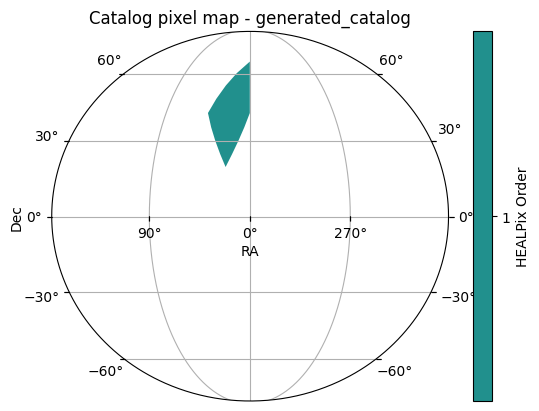

In [56]:
import matplotlib.pyplot as plt

fig = plt.figure()

cat = lsdb.open_catalog("catalogs/catalog1/generated_catalog")
_,ax = cat.plot_pixels()
fig.add_axes(ax)
fig.show()

In [65]:
#cat1 = lsdb.generate_catalog(5000,100, lowest_order=1, ra_range=(15.0,25.0), dec_range=(34.0,44.0), seed=1)
#cat1.write_catalog("catalogs/catalog1", overwrite=True)

#cat2 = lsdb.generate_catalog(5000,100, lowest_order=4, ra_range=(15.0,25.0), dec_range=(34.0,44.0), seed=1)
#cat2.write_catalog("catalogs/catalog2", overwrite=True)

cat3 = lsdb.generate_catalog(5000,100, lowest_order=7, ra_range=(15.0,25.0), dec_range=(34.0,44.0), seed=1)
cat3.write_catalog("catalogs/catalog3", overwrite=True)

cat4 = cat3.query("a>0.95")
cat4.write_catalog("catalogs/catalog4", overwrite=True)

#cat5 = lsdb.generate_catalog(1000000,2, ra_range=(15.0,25.0), dec_range=(34.0,44.0), seed=1)
#cat5.write_catalog("catalogs/catalog5",overwrite=True)

#cat6 = lsdb.generate_catalog(5000,100, ra_range=(0,180), dec_range=(0,90), seed=1)
#cat6.write_catalog("catalogs/catalog6",overwrite=True)

#cat7 = lsdb.generate_catalog(50000,100, lowest_order=4, ra_range=(0,180), dec_range=(0,90), seed=1)
#cat7.write_catalog("catalogs/catalog7",overwrite=True)

#cat8 = lsdb.generate_catalog(5000,100, lowest_order=5, ra_range=(0,180), dec_range=(0,90), seed=1)
#cat8.write_catalog("catalogs/catalog8",overwrite=True)

Writing Catalog:   0%|          | 0/1628 [00:00<?, ?it/s]

Writing Margin Cache:   0%|          | 0/492 [00:00<?, ?it/s]

Writing Catalog:   0%|          | 0/1628 [00:00<?, ?it/s]

Writing Margin Cache:   0%|          | 0/492 [00:00<?, ?it/s]

## Challenges

### Challenge 1: Load a Catalog
Loading will be a part of all further challenges implicitly

In [9]:
def chal1():
    return lsdb.open_catalog("catalogs/catalog2/generated_catalog")

In [3]:
cat = chal1()

measure_metrics(cat, with_client=False, optimize=False)
cat

# of Graph Tasks: 36
Graph Size: 0.253296 MB
Execution Time: 0.04086 seconds


,ra,dec,id,a,b,nested
npartitions=12,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."
"Order: 4, Pixel: 140",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...


### Challenge 2: Query a Catalog

In [10]:
def chal2():
    cat = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    return cat.query("nested.t>0.3")

In [5]:

cat = chal2()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/49 [00:00<?, ?it/s]

# of Graph Tasks: 12
Graph Size: 0.38862 MB
Execution Time: 0.14053 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 12
Graph Size: 0.38862 MB
Execution Time: 1.69123 seconds


,ra,dec,id,a,b,nested
npartitions=12,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."
"Order: 4, Pixel: 140",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...


### Challenge 3: `map_rows`

In [11]:
def chal3():
    cat = lsdb.open_catalog("catalogs/catalog2/generated_catalog")

    def my_sigma(row):
       '''map_rows will return a NestedFrame with two columns'''
       return row["nested.flux"] + 1, row["nested.flux"] - 1
    meta = {"plus_one": np.float64, "minus_one": np.float64}
    cat = cat.map_rows(my_sigma,
                       columns=["nested.flux"],
                       output_names=["plus_one", "minus_one"],
                       meta=meta)
    return cat

In [7]:
cat = chal3()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/49 [00:00<?, ?it/s]

# of Graph Tasks: 12
Graph Size: 0.34026 MB
Execution Time: 0.13625 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 12
Graph Size: 0.34026 MB
Execution Time: 1.83247 seconds


,plus_one,minus_one
npartitions=12,,
"Order: 4, Pixel: 139",float64,float64
"Order: 4, Pixel: 140",...,...
...,...,...
"Order: 4, Pixel: 167",...,...
"Order: 4, Pixel: 176",...,...


### Challenge 4: Partition Selection

In [12]:
def chal4():
    cat = lsdb.open_catalog("catalogs/catalog4/generated_catalog").partitions[2]
    return cat

In [9]:
cat = chal4()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

# of Graph Tasks: 1
Graph Size: 0.025969 MB
Execution Time: 0.00848 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 1
Graph Size: 0.0258 MB
Execution Time: 1.22813 seconds


,ra,dec,id,a,b,nested
npartitions=1,,,,,,
"Order: 7, Pixel: 8953",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."


### Challenge 5: Crossmatch 1

In [13]:
def chal5():
    l1 = lsdb.open_catalog("catalogs/catalog1/generated_catalog")
    l2 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")

    cat = l1.crossmatch(l2, suffixes=("_l","_r"), suffix_method='all_columns')
    return cat

In [11]:
cat = chal5()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/90 [00:00<?, ?it/s]

# of Graph Tasks: 91
Graph Size: 1.062974 MB
Execution Time: 0.17488 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 91
Graph Size: 0.966164 MB
Execution Time: 1.9229 seconds


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=12,,,,,,,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]
"Order: 4, Pixel: 140",...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...,...,...,...,...,...,...,...


### Challenge 6: Crossmatch 2

In [14]:
def chal6():
    l1 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    l2 = lsdb.open_catalog("catalogs/catalog3/generated_catalog")

    cat = l1.crossmatch(l2, suffixes=("_l","_r"), suffix_method='all_columns')
    return cat

In [13]:
cat = chal6()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/2899 [00:00<?, ?it/s]

# of Graph Tasks: 2878
Graph Size: 31.60113 MB
Execution Time: 4.21908 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 2878
Graph Size: 32.106907 MB
Execution Time: 14.50703 seconds


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=407,,,,,,,,,,,,,
"Order: 7, Pixel: 8927",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]
"Order: 7, Pixel: 8943",...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 11296",...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 11298",...,...,...,...,...,...,...,...,...,...,...,...,...


### Challenge 7: Crossmatch 3

In [15]:
def chal7():
    l1 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    l2 = lsdb.open_catalog("catalogs/catalog7/generated_catalog")

    cat = l1.crossmatch(l2, suffixes=("_l","_r"), suffix_method='all_columns')
    return cat

In [15]:
cat = chal7()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False, optimize=True)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/134 [00:00<?, ?it/s]

# of Graph Tasks: 1661
Graph Size: 19.744329 MB
Execution Time: 0.26413 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 1661
Graph Size: 19.745308 MB
Execution Time: 2.23487 seconds


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=12,,,,,,,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]
"Order: 4, Pixel: 140",...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...,...,...,...,...,...,...,...


### Challenge 8: Search Filters

In [16]:
def chal8():
    return lsdb.open_catalog("catalogs/catalog8/generated_catalog", search_filter=lsdb.BoxSearch(ra=(15,25), dec=(34.0,44.0)))

In [17]:
cat = chal8()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/101 [00:00<?, ?it/s]

# of Graph Tasks: 25
Graph Size: 0.9258 MB
Execution Time: 0.09575 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 25
Graph Size: 0.9258 MB
Execution Time: 1.93215 seconds


,ra,dec,id,a,b,nested
npartitions=25,,,,,,
"Order: 7, Pixel: 8956",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."
"Order: 7, Pixel: 9007",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 5, Pixel: 705",...,...,...,...,...,...
"Order: 5, Pixel: 706",...,...,...,...,...,...


### Challenge 9: `from_dataframe` backed graphs

`from_dataframe` will encode the data directly into the graphs, resulting in much worse graph sizes

In [18]:
def chal9():
    cat = lsdb.generate_catalog(5000,100, lowest_order=4, ra_range=(15.0,25.0), dec_range=(34.0,44.0), seed=1) # catalog 2
    return cat.query("nested.t>0.3")

In [19]:
cat = chal9()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/61 [00:00<?, ?it/s]

# of Graph Tasks: 48
Graph Size: 15.25344 MB
Execution Time: 0.10345 seconds
-----------------------
With Distributed Client
-----------------------


/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 14.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


# of Graph Tasks: 48
Graph Size: 15.25344 MB
Execution Time: 0.84433 seconds


,ra,dec,id,a,b,nested
npartitions=12,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."
"Order: 4, Pixel: 140",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...


### Challenge 10: `map_partitions`

In [19]:
def chal10():
    cat = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    def add_flag(df):
        return df.assign(in_north=df["dec"] > 0)
    result = cat.map_partitions(add_flag)
    return result

In [21]:
cat = chal10()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/61 [00:00<?, ?it/s]

# of Graph Tasks: 12
Graph Size: 0.54672 MB
Execution Time: 0.05086 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 12
Graph Size: 0.54672 MB
Execution Time: 1.50891 seconds


,ra,dec,id,a,b,nested,in_north
npartitions=12,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",bool[pyarrow]
"Order: 4, Pixel: 140",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...,...


## Challenge 11: `map_partitions` -> query

In [20]:
def chal11():
    cat = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    def add_flag(df):
        return df.assign(in_north=df["dec"] > 0)
    result = cat.map_partitions(add_flag)
    return result.query("in_north==True")

In [23]:
cat = chal11()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/73 [00:00<?, ?it/s]

# of Graph Tasks: 12
Graph Size: 0.667212 MB
Execution Time: 0.09619 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 12
Graph Size: 0.667212 MB
Execution Time: 1.53929 seconds


,ra,dec,id,a,b,nested,in_north
npartitions=12,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",bool[pyarrow]
"Order: 4, Pixel: 140",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...,...


### Challenge 12: 1-to-Many Crossmatch

In [21]:
def chal12():
    l1 = lsdb.open_catalog("catalogs/catalog5/generated_catalog")
    l2 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")

    cat = l1.crossmatch(l2, suffixes=("_l","_r"), suffix_method='all_columns')
    return cat

In [25]:
cat = chal12()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

--------------------------
Without Distributed Client
--------------------------


/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


Computing Catalog:   0%|          | 0/90 [00:00<?, ?it/s]

# of Graph Tasks: 91
Graph Size: 0.965795 MB
Execution Time: 0.42163 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 91
Graph Size: 0.941865 MB
Execution Time: 2.32958 seconds


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=12,,,,,,,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]
"Order: 4, Pixel: 140",...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...,...,...,...,...,...,...,...


### Challenge 13: Many-to-1 Crossmatch
Just Challenge 12, but flipped, note the increase in execution time

In [22]:
def chal13():
    l1 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    l2 = lsdb.open_catalog("catalogs/catalog5/generated_catalog")

    cat = l1.crossmatch(l2, suffixes=("_l","_r"), suffix_method='all_columns')
    return cat

In [27]:
cat = chal13()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/90 [00:00<?, ?it/s]

# of Graph Tasks: 91
Graph Size: 0.914339 MB
Execution Time: 1.55735 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 91
Graph Size: 0.964657 MB
Execution Time: 7.48015 seconds


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=12,,,,,,,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]
"Order: 4, Pixel: 140",...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 167",...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 176",...,...,...,...,...,...,...,...,...,...,...,...,...


### Challenge 14: Crossmatch Partition Selection

In [23]:
def chal14():
    l1 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
    l2 = lsdb.open_catalog("catalogs/catalog7/generated_catalog")

    cat = l1.crossmatch(l2, suffixes=("_l","_r"), suffix_method='all_columns')
    return cat.partitions[0]

In [3]:
cat = chal14()

print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
cat

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


--------------------------
Without Distributed Client
--------------------------


Computing Catalog:   0%|          | 0/14 [00:00<?, ?it/s]

# of Graph Tasks: 1641
Graph Size: 19.338559 MB
Execution Time: 0.10591 seconds
-----------------------
With Distributed Client
-----------------------
# of Graph Tasks: 1641
Graph Size: 19.314241 MB
Execution Time: 1.63253 seconds


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=1,,,,,,,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]


In [33]:
#with Client(n_workers=1, threads_per_worker=1, dashboard_address=':8326') as client:
    #chal7()._ddf.analyze()
    #chal7()._ddf.optimize().analyze()
    #client.close()


In [40]:
#chal7()._ddf.__dask_graph__()

In [5]:
from dask.highlevelgraph import HighLevelGraph

In [6]:
hlg = HighLevelGraph.from_collections("chal14", chal14()._ddf.dask, dependencies=[chal14()._ddf])
hlg

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


HighLevelGraph with 2 layers.
<dask.highlevelgraph.HighLevelGraph object at 0x16bac6690>
 0. 6102916832
 1. chal14

In [7]:
chal14()

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


,ra_l,dec_l,id_l,a_l,b_l,nested_l,ra_r,dec_r,id_r,a_r,b_r,nested_r,_dist_arcsec
npartitions=1,,,,,,,,,,,,,
"Order: 4, Pixel: 139",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str...",double[pyarrow]


In [63]:
chal14()._ddf.__dask_keys__()

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


[('partitions-f80e1d7a263dd3bc9d237b2318724321', 0)]

### Challenge : LSDB Streaming -- Won't Do

In [32]:
from lsdb.streams import CatalogStream
def chalX():
    cat = lsdb.open_catalog("catalogs/catalog4/generated_catalog")
    cat_stream = CatalogStream(cat, shuffle=False)
    return next(iter(cat_stream)) # grab a single partition and compute
cat = chalX()

# Can't do this because next is auto-computed, so we don't yield a graph
"""
print("--------------------------")
print("Without Distributed Client")
print("--------------------------")
measure_metrics(cat, with_client=False)

print("-----------------------")
print("With Distributed Client")
print("-----------------------")
measure_metrics(cat, with_client=True, dashboard_address=':8325')
"""
print()

## Report All Challenge Metrics

In [24]:
import pandas as pd
def challenge_report(graph_list, with_client=False, optimize=True):
    results = {"challenge":[],"graph_tasks":[], "graph_size (MB)":[], "compute_time (s)":[]}
    for i,cat in enumerate(graph_list):
        ntasks, graph_size, compute_time = measure_metrics(cat, with_client=with_client, verbose=False, optimize=optimize, dashboard_address=':8325')
        results["graph_tasks"] = results["graph_tasks"] + [ntasks]
        results["graph_size (MB)"] = results["graph_size (MB)"] + [graph_size/10**6]
        results["compute_time (s)"] = results["compute_time (s)"] + [compute_time]
        results["challenge"] = results["challenge"] + [i+1]
    return results

challenge_list = [chal1(),chal2(),chal3(),chal4(),chal5(),chal6(),chal7(), chal8(), chal9(), chal10(),chal11(),chal12(),chal13(),chal14()]
results_nocli = challenge_report(challenge_list)
results_cli = challenge_report(challenge_list, with_client=True)
results_nocli_noopt = challenge_report(challenge_list, optimize=False)
results_cli_noopt = challenge_report(challenge_list, with_client=True, optimize=False)

nocli_df = pd.DataFrame(results_nocli).set_index("challenge")
nocli_df["client"] = False

cli_df = pd.DataFrame(results_cli).set_index("challenge")
cli_df["client"] = True

joined_df = pd.concat([nocli_df,cli_df]).sort_values(by="challenge")
joined_df

nocli_noopt_df = pd.DataFrame(results_nocli_noopt).set_index("challenge")
nocli_noopt_df["client"] = False

cli_noopt_df = pd.DataFrame(results_cli_noopt).set_index("challenge")
cli_noopt_df["client"] = True

joined_noopt_df = pd.concat([nocli_noopt_df,cli_noopt_df]).sort_values(by="challenge")
comp_df = joined_noopt_df.compare(joined_df, keep_equal=True, keep_shape=True, result_names=('No Optimize()', 'Optimize()'))
comp_df

/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/dask/crossmatch_catalog_data.py:326: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(
/Users/dbranton/lincc/lsd

Computing Catalog:   0%|          | 0/37 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/49 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/49 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

...

Computing Catalog:   0%|          | 0/90 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/90 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/14 [00:00<?, ?it/s]

/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 14.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 14.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


graph_tasks            graph_size (MB)             \
          No Optimize() Optimize()   No Optimize() Optimize()   
challenge                                                       
1                    36         12        0.251232   0.284076   
1                    36         12        0.251232   0.284076   
2                    48         12        0.349656   0.386556   
2                    48         12        0.347592   0.384492   
3                    48         12        0.304128   0.340260   
3                    48         12        0.302064   0.338196   
4                     4          1        0.024579   0.025949   
4                     4          1        0.024568   0.025925   
5                   130         91        0.859505   0.941652   
5                   130         91        0.861674   0.990580   
6                  4124       2878       27.214529  31.430897   
6                  4124       2878       27.363499  32.081857   
7                  3282       1661       17.347280  19.633821   
7                  3282       1661       17.298517  19.656771   
8                   125         25        0.907425   0.925800   
8                   125         25        0.907425   0.925800   
9                    72         48       15.212112  15.253440   
9                    72         48       15.212112  15.253440   
10                   60         12        0.502380   0.546720   
10                   60         12        0.502380   0.546720   
11                   72         12        0.617424   0.665148   
11                   72         12        0.619488   0.667212   
12                  130         91        0.834436   0.965400   
12                  130         91        0.862183   0.967016   
13                  130         91        0.785991   0.987440   
13                  130         91        0.812683   0.990418   
14                 3283       1641       17.446102  19.176022   
14                 3283       1641       17.348479  19.175804   

          compute_time (s)                   client             
             No Optimize() Optimize() No Optimize() Optimize()  
challenge                                                       
1                 0.035216   0.042735         False      False  
1                 1.562047   1.676921          True       True  
2                 0.239181   0.110833         False      False  
2                 1.431576   1.434411          True       True  
3                 0.119876   0.125680         False      False  
3                 1.343287   1.574948          True       True  
4                 0.005222   0.008684         False      False  
4                 1.121295   1.353750          True       True  
5                 0.151556   0.165491         False      False  
5                 1.896373   1.732489          True       True  
6                 3.878985   3.929482         False      False  
6                13.793427  13.696121          True       True  
7                 0.176774   0.283837         False      False  
7                 2.041029   1.980194          True       True  
8                 1.473994   1.477473          True       True  
8                 0.084722   0.092286         False      False  
9                 0.079826   0.398918         False      False  
9                 0.731580   0.741587          True       True  
10                1.489845   1.462629          True       True  
10                0.037410   0.073446         False      False  
11                1.497555   1.610549          True       True  
11                0.078554   0.127855         False      False  
12                2.166106   2.311346          True       True  
12                0.335645   0.416774         False      False  
13                6.770199   6.900010          True       True  
13                1.447508   1.428935         False      False  
14                0.079151   0.083007         False      False  
14                1.292868   1.330894         